# Modelo preliminar de clasificación

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer

RANDOM_STATE = 42
DATA = Path("../data/train_clean.csv")
df = pd.read_csv(DATA)
df.shape

(7484, 10)

## 1. Verificación del dataset preprocesado

In [3]:
print(f"Filas: {len(df)}")
print(df["target"].value_counts(normalize=True).round(3))
df[["text", "text_final"]].head()

Filas: 7484
target
0    0.574
1    0.426
Name: proportion, dtype: float64


,text,text_final
0,Our Deeds are the Reason of this #earthquake M...,deed reason earthquake may allah forgive
1,Forest fire near La Ronge Sask. Canada,forest fire near ronge sask canada
2,All residents asked to 'shelter in place' are ...,resident asked shelter place notified officer ...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfire evacuation order calif...
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo ruby alaska smoke wildfire pour...


## 2. Split train/test

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text_final"], df["target"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df["target"]
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")

Train: 5987  Test: 1497


## 3. Vectorización: TF-IDF con unigramas y bigramas

In [5]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=8000,
    min_df=2
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
X_train_vec.shape

(5987, 8000)

## Frecuencia de n-gramas por categoría

Se calcula la frecuencia de unigramas, bigramas y trigramas por separado en tweets de desastre real (target=1) y no desastre (target=0), usando `CountVectorizer` sobre `text_final`, para identificar qué términos y combinaciones de palabras distinguen mejor a cada clase.

In [6]:
def top_ngrams(textos, ngram_range, top_n=15):
    vec = CountVectorizer(ngram_range=ngram_range, min_df=2)
    X = vec.fit_transform(textos)
    freqs = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    return (pd.DataFrame({"ngram": vocab, "freq": freqs})
            .sort_values("freq", ascending=False)
            .head(top_n))

print("Unigramas más frecuentes - DESASTRE ")
print(top_ngrams(df.loc[df.target == 1, "text_final"], (1, 1)))

print("\nUnigramas más frecuentes - NO DESASTRE")
print(top_ngrams(df.loc[df.target == 0, "text_final"], (1, 1)))

print("\nBigramas más frecuentes - DESASTRE")
print(top_ngrams(df.loc[df.target == 1, "text_final"], (2, 2)))

print("\nBigramas más frecuentes - NO DESASTRE ")
print(top_ngrams(df.loc[df.target == 0, "text_final"], (2, 2)))

print("\nTrigramas más frecuentes - DESASTRE")
print(top_ngrams(df.loc[df.target == 1, "text_final"], (3, 3), top_n=10))

print("\nTrigramas más frecuentes - NO DESASTRE")
print(top_ngrams(df.loc[df.target == 0, "text_final"], (3, 3), top_n=10))

Unigramas más frecuentes - DESASTRE 
           ngram  freq
962         fire   261
1735         not   215
1712        news   137
2722         via   119
723     disaster   116
385   california   114
1920      police   107
2454     suicide   106
920       family   102
1860      people   102
1206        home   102
2424       storm    95
1368      killed    95
2608       train    92
2863        year    92

Unigramas más frecuentes - NO DESASTRE
       ngram  freq
2158     not   533
1837    like   254
1349     get   185
2128     new   171
3541   would   142
2206     one   139
386     body   119
813      day   102
3212    time   102
3391   video   101
3386     via    98
1902    love    96
1382     got    92
1757    know    91
2303  people    91

Bigramas más frecuentes - DESASTRE
                    ngram  freq
1966       suicide bomber    55
1426  northern california    41
1483            oil spill    38
306   california wildfire    36
1967      suicide bombing    34
969            home raz

**Hallazgos:**

Los unigramas por sí solos son poco distintivos. La palabra más frecuente en ambas clases es la misma (`not`), y términos como `via` o `people` aparecen con frecuencia parecida sin importar la categoría. Sí hay vocabulario propio de los desastres reales (`fire`, `disaster`, `killed`, `storm`, `police`), pero se mezcla con ese ruido de palabras compartidas entre ambas clases.

Los bigramas resultan mucho más informativos. En tweets de desastre aparecen combinaciones claras y específicas como `suicide bomber`,
`california wildfire`, `oil spill` o `severe thunderstorm`. En cambio, en los tweets de no-desastre predominan expresiones coloquiales o de otro contexto, como `look like`, `feel like` o `liked video`. Esto es justo el tipo de ambigüedad que un modelo de solo unigramas no puede resolver, porque la palabra `body` sola no distingue el contexto.

Los trigramas muestran el mismo patrón pero con eventos todavía más puntuales y específicos (`northern california wildfire`, `suicide bomber
detonated`), lo que los hace más precisos para casos concretos, aunque menos generalizables. Aparecen pocas veces en el dataset, con lo cual el modelo podría sobreajustarse a ellos en vez de aprender patrones que se repitan en tweets nuevos.

**Conclusión:** sí vale la pena usar bigramas junto a unigramas (como ya se hizo en la vectorización TF-IDF del modelo), porque capturan contexto que el unigrama solo no distingue. Los trigramas aportan información adicional pero con mayor riesgo de sobreajuste por su baja frecuencia, por lo que no se incluyeron en el modelo final.

## 4. Modelos candidatos

- **Regresión Logística**: modelo lineal, interpretable, buen punto de partida para texto disperso tipo TF-IDF.
- **Naive Bayes multinomial**: clásico para clasificación de texto, rápido y buen baseline.
- **SVM (Linear)**: suele funcionar muy bien con vectores TF-IDF de alta dimensión y dispersos.
- **Random Forest**: modelo de ensamble no lineal, como contraste frente a los modelos lineales.

In [7]:
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Multinomial Naive Bayes": MultinomialNB(),
    "SVM (Linear)": LinearSVC(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

resultados = []
predicciones = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train_vec, y_train)
    pred = modelo.predict(X_test_vec)
    predicciones[nombre] = pred
    resultados.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
    })

resultados_df = pd.DataFrame(resultados).sort_values("f1", ascending=False).reset_index(drop=True)
resultados_df

,modelo,accuracy,precision,recall,f1
0,Logistic Regression,0.796259,0.826772,0.659341,0.733624
1,Random Forest,0.786239,0.791897,0.675039,0.728814
2,Multinomial Naive Bayes,0.796259,0.856223,0.626374,0.723481
3,SVM (Linear),0.770207,0.759292,0.673469,0.713810


## 5. Comparación visual

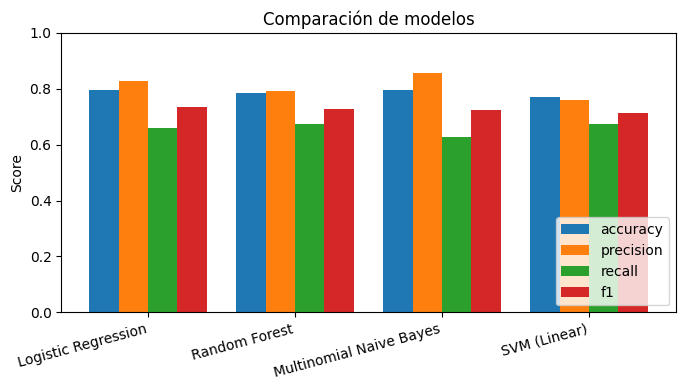

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(resultados_df))
width = 0.2
for i, metrica in enumerate(["accuracy", "precision", "recall", "f1"]):
    ax.bar(x + i * width, resultados_df[metrica], width, label=metrica)
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(resultados_df["modelo"], rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Comparación de modelos")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../output/comparacion_modelos.png", dpi=150)
plt.show()

## 6. Modelo seleccionado

In [9]:
mejor_modelo_nombre = resultados_df.iloc[0]["modelo"]
print(f"Modelo seleccionado: {mejor_modelo_nombre}")
cm = confusion_matrix(y_test, predicciones[mejor_modelo_nombre])
pd.DataFrame(cm, index=["Real: 0", "Real: 1"], columns=["Pred: 0", "Pred: 1"])

Modelo seleccionado: Logistic Regression


,Pred: 0,Pred: 1
Real: 0,772,88
Real: 1,217,420


**Justificación:** se selecciona el modelo con mejor F1 (balance entre precision y recall), ya que ambos tipos de error importan en este problem. Un falso negativo puede significar no detectar un desastre real, y un falso positivo genera ruido/alarmas innecesarias. El F1 evita optimizar solo accuracy, que puede ser engañoso si las clases no están perfectamente balanceadas (57%/43% en este caso).

## 7. Validación cruzada del modelo seleccionado

Para verificar que el desempeño de la Regresión Logística no depende de cómo cayó el split 80/20, se corre una validación cruzada con k=5 folds sobre todos los datos vectorizados, usando F1 como métrica.

In [10]:
X_all_vec = vectorizer.transform(df["text_final"])
y_all = df["target"]

cv_estrategia = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_all_vec, y_all,
    cv=cv_estrategia, scoring="f1"
)

print("F1 por fold:", np.round(cv_scores, 3))
print(f"F1 promedio: {cv_scores.mean():.3f}  (± {cv_scores.std():.3f})")

F1 por fold: [0.742 0.727 0.763 0.748 0.751]
F1 promedio: 0.746  (± 0.012)


## 8. Guardar el modelo final para la función de clasificación

Se reentrena el modelo ganador (Regresión Logística) usando el 100% de los datos disponibles, ya que la evaluación con métricas se hizo con el split anterior. Se guardan el modelo y el vectorizador TF-IDF por separado con `joblib`, para que la función de clasificación pueda cargarlos sin necesidad de reentrenar.

In [11]:
X_full_vec = vectorizer.transform(df["text_final"])
modelo_final = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
modelo_final.fit(X_full_vec, df["target"])

joblib.dump(modelo_final, "../output/modelo_final.pkl")
joblib.dump(vectorizer, "../output/vectorizer.pkl")
print("Modelo y vectorizador guardados en ../output/")

modelo_cargado = joblib.load("../output/modelo_final.pkl")
vec_cargado = joblib.load("../output/vectorizer.pkl")

ejemplo = ["forest fire spreading near town evacuation order"]
ejemplo_vec = vec_cargado.transform(ejemplo)
print("Predicción de prueba:", modelo_cargado.predict(ejemplo_vec))

Modelo y vectorizador guardados en ../output/
Predicción de prueba: [1]
